In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

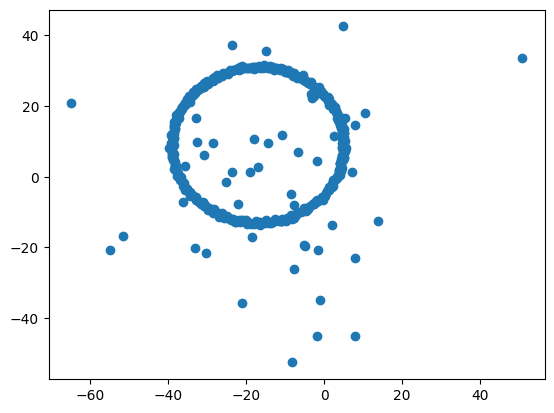

In [65]:
df = pd.read_csv('RANSACdataHakonsen.txt', sep='\t', header=None)
df = df.dropna(axis=1, how='all')
df.columns = ['x', 'y']

plt.scatter(df['x'] , df['y'])
plt.show()

In [58]:
def RANSAC_fitting(df, distance, min_inliers, epochs):
    circ = []

    for _ in range(epochs):

        st = df.sample(n=3)

        x_1, y_1 = st.iloc[0]
        x_2, y_2 = st.iloc[1]
        x_3, y_3 = st.iloc[2]

        D = 2 * (
            x_1 * (y_2 - y_3) +
            x_2 * (y_3 - y_1) +
            x_3 * (y_1 - y_2)
        )

        if abs(D) < distance:
            continue

        x_c = (
            (x_1**2 + y_1**2) * (y_2 - y_3) +
            (x_2**2 + y_2**2) * (y_3 - y_1) +
            (x_3**2 + y_3**2) * (y_1 - y_2)
        ) / D

        y_c = (
            (x_1**2 + y_1**2) * (x_3 - x_2) +
            (x_2**2 + y_2**2) * (x_1 - x_3) +
            (x_3**2 + y_3**2) * (x_2 - x_1)
        ) / D

        r = np.sqrt((x_1 - x_c)**2 + (y_1 - y_c)**2)

        num_inliers = 0

        for x_p, y_p in zip(df["x"], df["y"]):
            dist = np.sqrt((x_p - x_c)**2 + (y_p - y_c)**2)
            error = abs(dist - r)

            if error < distance:
                num_inliers += 1

        if num_inliers >= min_inliers:
            circ.append({
                "inliners": num_inliers,
                "r": r,
                "c": (x_c, y_c)
            })

    if len(circ) == 0:
        return None

    best_circle = max(circ, key=lambda c: c["inliners"])

    return best_circle


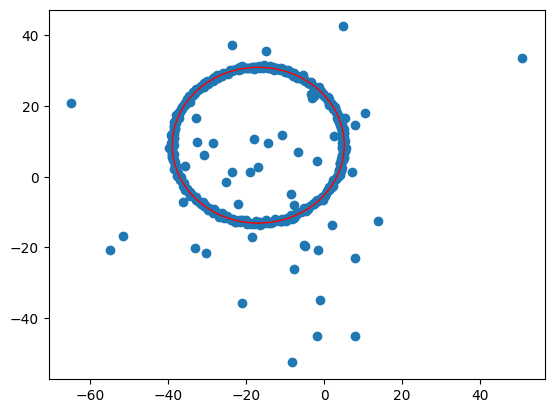

In [64]:
best_circle = RANSAC_fitting(df,0.1, 5, 15)
r = best_circle['r']
c = best_circle['c']
inliners = best_circle['inliners']


fig, ax = plt.subplots()
ax.scatter(df['x'], df['y'])
circle = plt.Circle(c, r, edgecolor='red', fill=False)
ax.add_patch(circle)
plt.show()


